# Main

In [2]:
##########################################################################
import os

# set the environment variable to control the number of threads
# NEEDS TO BE DONE BEFORE CCL IS IMPORTED
original_omp_num_threads = os.environ.get('OMP_NUM_THREADS', None)
os.environ['OMP_NUM_THREADS'] = '1'

# Generic
import pandas as pd
import numpy as np
import scipy
from itertools import islice, cycle
import math
import sys
from scipy.integrate import odeint
from joblib import Parallel, delayed
import itertools
from importlib import reload
from functools import lru_cache
import scipy.integrate
import baccoemu
import subprocess
import multiprocessing

# cosmology
import pyccl as ccl
from astropy.io import fits
import yaml
import sacc
import time

# Generate data sets
from sklearn.datasets import make_blobs
import sklearn
#print(sklearn.__version__) # should be 1.3.2

# PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# SRD Binning
import srd_redshift_distributions as srd
import binning

# Data Visualization
import matplotlib.pyplot as plt
from tabulate import tabulate
import matplotlib.patches as mpatches
import matplotlib
#import seaborn as sns

# MCMC
import emcee
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import corner
from chainconsumer import ChainConsumer, Chain, make_sample
from IPython.display import display, Math
from multiprocessing import Pool, cpu_count
from tqdm import tqdm
import gc

# Profiling
import cProfile
import pstats
from IPython.display import HTML

2024-11-28 13:05:37.779329: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-28 13:05:37.780055: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-28 13:05:37.783938: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-28 13:05:37.793409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1732799137.808516 1592435 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1732799137.81

In [3]:
print(emcee.__version__)
print(ccl.__version__)


3.1.6
3.0.0


In [4]:
from LikelihoodFuncts_PCADR_muSigma import *

Loading model and related data


/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.24.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 0.24.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
# Define cosmology
cosmo_universe = ccl.Cosmology(Omega_c = 0.269619, 
                          Omega_b = 0.050041,
                          h = 0.6688,
                          n_s = 0.9626,
                          A_s = 2.092e-9)

In [6]:
##########################################################################
#### Set up background things ####
# Define the redshift interval and forecast years
redshift_range = np.linspace(0.01, 3.5, 500)
forecast_years = ["1", "10"]  # Assuming integers are appropriate

# Create a dictionary to store the redshift distributions
# for each forecast year and galaxy sample
redshift_distribution = {
    "sources": {},
    "lenses": {}
}

for year in forecast_years:
    source_dist = srd.SRDRedshiftDistributions(redshift_range, 
                                               galaxy_sample="source_sample",
                                               forecast_year=year)
    lens_dist = srd.SRDRedshiftDistributions(redshift_range, 
                                             galaxy_sample="lens_sample",
                                             forecast_year=year)

    redshift_distribution["sources"][year] = source_dist.get_redshift_distribution(normalised=True,
                                                                                   save_file=False)
    redshift_distribution["lenses"][year] = lens_dist.get_redshift_distribution(normalised=True,
                                                                                save_file=False)

# Uncomment to check if the dictionary is populated correctly
# print(redshift_distribution["sources"].keys())


bins = {
    "sources": {},
    "lenses": {}
}

# Perform the binning procedure
for year in forecast_years:
    bins["sources"][year] = binning.Binning(redshift_range, 
                                            redshift_distribution["sources"][year],
                                            year).source_bins(normalised=True,
                                                              save_file=False)
    bins["lenses"][year] = binning.Binning(redshift_range, 
                                           redshift_distribution["lenses"][year],
                                           year).lens_bins(normalised=True,
                                                           save_file=False)


#(5, 256)
Binned_distribution_lens = [list(bins["lenses"]["1"].items())[0][1]]
for i in range(4):
    Binned_distribution_lens = np.append(Binned_distribution_lens,\
               [list(bins["lenses"]["1"].items())[i+1][1]], axis=0)

Binned_distribution_source = [list(bins["sources"]["1"].items())[0][1]]
for i in range(4):
    Binned_distribution_source = np.append(Binned_distribution_source,\
               [list(bins["sources"]["1"].items())[i+1][1]], axis=0)


Bias_distribution_fiducial = np.array([1.562362*np.ones(len(redshift_range)),
                             1.732963*np.ones(len(redshift_range)),
                             1.913252*np.ones(len(redshift_range)),
                             2.100644*np.ones(len(redshift_range)),
                             2.293210*np.ones(len(redshift_range))])

binned_ell_test = bin_ell_kk(20, 1478.5, 13, Binned_distribution_source)

P_delta2D_GR_lin_universe = Get_Pk2D_obj_kk_GR_lin(cosmo_universe)
P_delta2D_GR_nl_universe = Get_Pk2D_obj_kk_GR_nl(cosmo_universe)

In [7]:
value1 = [cosmo_universe["Omega_c"], 0.0, 0.0,cosmo_universe["A_s"]*1e9, cosmo_universe["h"],\
          cosmo_universe["n_s"],cosmo_universe["Omega_b"]*cosmo_universe["h"]**2,\
         Bias_distribution_fiducial[0][0], Bias_distribution_fiducial[1][0],\
         Bias_distribution_fiducial[2][0],Bias_distribution_fiducial[3][0],\
         Bias_distribution_fiducial[4][0]]

In [8]:
#### Define log likelihood #####
def log_likelihood(theta, Data, InvCovmat,Data_fsigma8):
    Omega_c, mu0,Sigma0, A_s1e9, h, n_s, wb, b1, b2, b3, b4, b5 = theta 
    Bias_distribution = np.array([b1*np.ones(len(z)),
                             b2*np.ones(len(z)),
                             b3*np.ones(len(z)),
                             b4*np.ones(len(z)),
                             b5*np.ones(len(z))])
    #h = cosmo_universe["h"]
    #A_s = cosmo_universe["A_s"]
    A_s = A_s1e9*1e-9
    #n_s = cosmo_universe["n_s"]
    MGparams = [0.2,1e-4,1.0,mu0, Sigma0]

    cosmo = ccl.Cosmology(Omega_c = Omega_c, 
                      Omega_b = wb/h**2,
                      h = h,
                      n_s = n_s,
                      A_s = A_s)

    
    return loglikelihood_noscalecut(Data, cosmo, MGparams, InvCovmat, Bias_distribution, Data_fsigma8)

#### Get Planck priors #####
sampler_Planck_arr = np.load("Prior_Planck_arr.npy")
mu_prior = [cosmo_universe['n_s'], cosmo_universe["Omega_b"]*cosmo_universe["h"]**2]
cov_prior = np.cov(sampler_Planck_arr.T)

#### Define log prior #####
def log_prior(theta):
    Omega_c, mu0,Sigma0, A_s1e9, h, n_s, wb, b1, b2, b3, b4, b5 = theta 

    #flat priors
    if not (0.1 < Omega_c + wb/h**2 < 0.9 and -1.5 < mu0 < 1.5 and -1.5 < Sigma0 < 1.5 and mu0 <= 2*Sigma0 + 1.0 \
            and 0.5 < A_s1e9 < 5 and 0.55 < h < 0.91 \
           and 0.8 < b1 < 3.0 and 0.8 < b2 < 3.0 and 0.8 < b3 < 3.0 and 0.8 < b4 < 3.0 and 0.8 < b5 < 3.0):
        return -np.inf
        
    gauss_funct = scipy.stats.multivariate_normal(mu_prior, cov_prior)
    
    return gauss_funct.logpdf([n_s, wb])

In [9]:
### Load and collect the data for likelihood
#npzfile = np.load("../Biases_parametrization/Data_storage_fR.npz")
npzfile = np.load("Data_storage_fR_partial.npz")
npzfile_GR = np.load("../Parameter_inference_GR/Data_storage_GR.npz")

C_ell_data_mock = [npzfile['C_ell_data'],npzfile['ell_data'],npzfile['z'],npzfile['Binned_distribution_source'],\
                    npzfile['Binned_distribution_lens'],20,1478.5,13]

Data_fsigma8= [npzfile['z_eff_fsigma8'], npzfile['fsigma8_data'],np.matrix(npzfile['invcov_fsigma8'])]

L_choleski_inv = np.matrix(npzfile_GR['L_ch_inv'])

gauss_invcov_rotated = np.matrix(npzfile_GR['Inverse_cov'])

## Tests

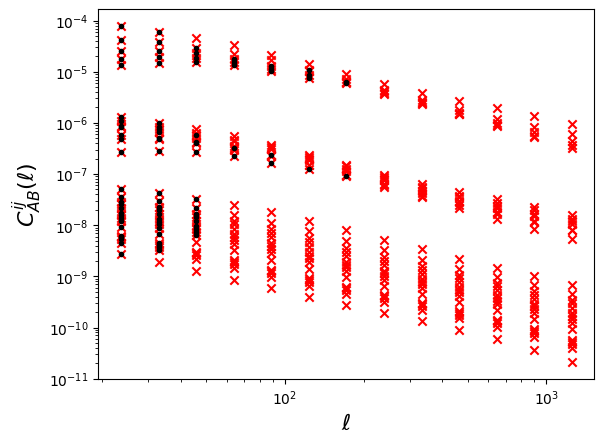

In [10]:
plt.scatter(npzfile['ell_data'],npzfile['C_ell_data'], color="r", marker='x')

for i in range(351):
    if gauss_invcov_rotated[0,i] !=0:
        plt.scatter(npzfile['ell_data'][i],npzfile['C_ell_data'][i], color="k", marker='.')

plt.xlabel("$\ell$",fontsize=16)
plt.ylabel("$C^{ij}_{AB}(\ell)$",fontsize=16)
plt.xscale("log")
plt.yscale("log")
#plt.savefig("LinearScaleCuts.pdf", bbox_inches='tight')


(351, 351)


/home/c2042999/PCA_project/Parameter_inference_fR/LikelihoodFuncts_PCADR_muSigma.py:1486: RuntimeWarning: invalid value encountered in divide
  return cov/np.outer(sig, sig)


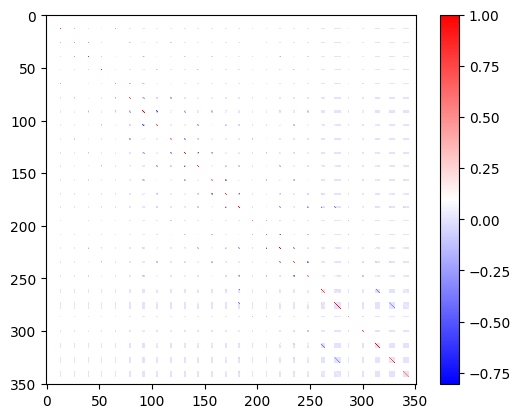

In [11]:
print(gauss_invcov_rotated.shape)
plt.imshow(cov2corr(gauss_invcov_rotated), origin='upper',  cmap='bwr')

plt.colorbar()
plt.show()

# Main

In [12]:
## add C_ell_data_mock, L_choleski_inv, Data_fsigma8
#### Define log probability #####
def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, C_ell_data_mock, gauss_invcov_rotated,Data_fsigma8)

In [13]:
command = 'python Likelihood_fR_parallel_mpi_StandardCuts_test.py'
os.system(command)

/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.24.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 0.24.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loading model and related data
lp fid=  [[-10.75852407]]
lp max=  [[-47.33098377]]


0

In [ ]:
command = 'python Likelihood_fR_parallel_mpi_noparam_StandardCuts_test.py'
os.system(command)

In [ ]:
# Set the random seed for reproducibility
np.random.seed(10)

# Initialize the walkers
Omega_c_est = 0.27
h_est = 0.7
A_s1e9_est = 2.1
n_s_est = 0.96
mu0_est = 0.1
Sigma0_est = 0.05
wb_est = 0.0223
b1_est = Bias_distribution_fiducial[0][0]
b2_est = Bias_distribution_fiducial[1][0]htop

b3_est = Bias_distribution_fiducial[2][0]
b4_est = Bias_distribution_fiducial[3][0]
b5_est = Bias_distribution_fiducial[4][0]

n_steps = 15000
chain_len = 100
converged = False
nwalkers = 80
print(cpu_count())
# Initialize the walkers
pos = [Omega_c_est, mu0_est,Sigma0_est, A_s1e9_est, h_est, n_s_est, wb_est,b1_est,b2_est,b3_est,b4_est,b5_est] \
+ np.append(np.append(1e-3 * np.random.randn(nwalkers, 5), 1e-5*np.random.randn(nwalkers, 2), axis = 1), \
            1e-3 * np.random.randn(nwalkers, 5), axis = 1)

nwalkers, ndim = pos.shape
print(nwalkers, ndim)

# Create the output directory and set up the HDF5 backend
mcmc_dir = "mcmc"
filename = mcmc_dir + "/mcmc_fR_muSigma_StandardCuts.h5"
backend = emcee.backends.HDFBackend(filename)

# Optionally reset the backend if starting a new run
#backend.reset(nwalkers, ndim)

with Pool(80) as pool:
    sampler_PCA = emcee.EnsembleSampler(nwalkers, ndim, log_probability, backend=backend, pool=pool)
    pos = sampler_PCA.get_last_sample() if backend.iteration > 0 else pos

    while not converged:
        gc.collect(generation=0)
        sampler_PCA.run_mcmc(pos, chain_len, progress=True, store=True)
        
        # Clear references in the worker pool
        pool.close()
        pool.join()
        del pool  # Ensure the pool object is removed
        gc.collect()  # Collect any lingering garbage
        pool = Pool(80)
        sampler_PCA.pool = pool
        pos = sampler_PCA.get_last_sample() if backend.iteration > 0 else pos
        
        # Check convergence
        try:
            tau = sampler_PCA.get_autocorr_time(tol=0)
            converged = np.all(tau * 100 < sampler_PCA.iteration)
        except emcee.autocorr.AutocorrError:
            pass

160
80 12


 22%|████████████████████████████████████▌                                                                                                                                 | 22/100 [02:27<08:33,  6.58s/it]